In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("datasets\\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df = df.drop(columns=["customerID"])

In [4]:
for col in df.select_dtypes(include="object").columns:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in gender: ['Female' 'Male']
Unique values in Partner: ['Yes' 'No']
Unique values in Dependents: ['No' 'Yes']
Unique values in PhoneService: ['No' 'Yes']
Unique values in MultipleLines: ['No phone service' 'No' 'Yes']
Unique values in InternetService: ['DSL' 'Fiber optic' 'No']
Unique values in OnlineSecurity: ['No' 'Yes' 'No internet service']
Unique values in OnlineBackup: ['Yes' 'No' 'No internet service']
Unique values in DeviceProtection: ['No' 'Yes' 'No internet service']
Unique values in TechSupport: ['No' 'Yes' 'No internet service']
Unique values in StreamingTV: ['No' 'Yes' 'No internet service']
Unique values in StreamingMovies: ['No' 'Yes' 'No internet service']
Unique values in Contract: ['Month-to-month' 'One year' 'Two year']
Unique values in PaperlessBilling: ['Yes' 'No']
Unique values in PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Unique values in TotalCharges: ['29.85' '1889.5' '108.15' ... '34

In [5]:
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})
df['MultipleLines'].unique()

array(['No', 'Yes'], dtype=object)

In [6]:
for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df[col] = df[col].map({'No internet service': 'No', 'Yes': 'Yes', 'No': 'No'})
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in OnlineSecurity: ['No' 'Yes']
Unique values in OnlineBackup: ['Yes' 'No']
Unique values in DeviceProtection: ['No' 'Yes']
Unique values in TechSupport: ['No' 'Yes']
Unique values in StreamingTV: ['No' 'Yes']
Unique values in StreamingMovies: ['No' 'Yes']


In [7]:
for col in df.select_dtypes(include="object").columns:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in gender: ['Female' 'Male']
Unique values in Partner: ['Yes' 'No']
Unique values in Dependents: ['No' 'Yes']
Unique values in PhoneService: ['No' 'Yes']
Unique values in MultipleLines: ['No' 'Yes']
Unique values in InternetService: ['DSL' 'Fiber optic' 'No']
Unique values in OnlineSecurity: ['No' 'Yes']
Unique values in OnlineBackup: ['Yes' 'No']
Unique values in DeviceProtection: ['No' 'Yes']
Unique values in TechSupport: ['No' 'Yes']
Unique values in StreamingTV: ['No' 'Yes']
Unique values in StreamingMovies: ['No' 'Yes']
Unique values in Contract: ['Month-to-month' 'One year' 'Two year']
Unique values in PaperlessBilling: ['Yes' 'No']
Unique values in PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Unique values in TotalCharges: ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Unique values in Churn: ['No' 'Yes']


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [9]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [10]:
df_encoded = pd.get_dummies(df,columns=df.select_dtypes(include="object").columns, drop_first=True)

In [11]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,True,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,False,...,True,True,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [12]:
df_encoded.shape

(7043, 24)

In [13]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape

((5634, 23), (1409, 23), (5634,), (1409,))

In [14]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(Churn
 0    0.734647
 1    0.265353
 Name: proportion, dtype: float64,
 Churn
 0    0.734564
 1    0.265436
 Name: proportion, dtype: float64)

In [15]:
y_train.value_counts(), y_test.value_counts()

(Churn
 0    4139
 1    1495
 Name: count, dtype: int64,
 Churn
 0    1035
 1     374
 Name: count, dtype: int64)

In [16]:
logistic = LogisticRegression(max_iter=1000, random_state=7)
logistic.fit(X_train_scaled, y_train)
y_pred = logistic.predict(X_test_scaled)
def metrics(y_test, y_pred):
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Accuracy Score:", accuracy_score(y_test, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred))
metrics(y_test, y_pred)
y_pred_proba = logistic.predict_proba(X_test_scaled)[:, 1]
y_pred_proba[:5]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.88      1035
           1       0.67      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409

Confusion Matrix:
 [[934 101]
 [165 209]]
Accuracy Score: 0.8112136266855926
ROC AUC Score: 0.7306194941744815


array([0.25582152, 0.06322289, 0.27677587, 0.04026648, 0.41085114])

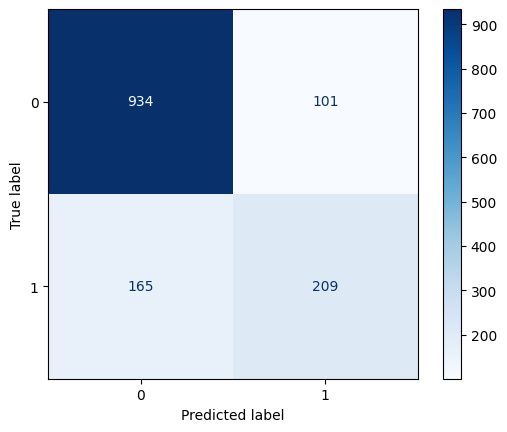

In [17]:
mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=logistic.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# balanced technique

In [18]:
logistic_balanced = LogisticRegression(max_iter=1000, random_state=7, class_weight='balanced')
logistic_balanced.fit(X_train_scaled, y_train)
y_pred = logistic_balanced.predict(X_test_scaled)
metrics(y_test, y_pred)

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.74      0.82      1035
           1       0.54      0.82      0.65       374

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409

Confusion Matrix:
 [[770 265]
 [ 66 308]]
Accuracy Score: 0.7650816181689141
ROC AUC Score: 0.7837453822108553


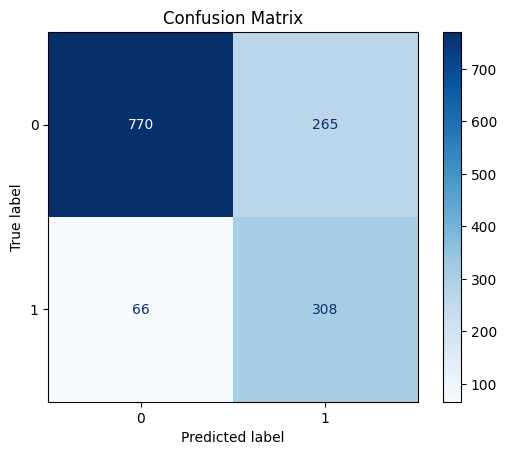

In [19]:
mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=logistic.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# under sampling technique

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.73      0.82      1035
           1       0.53      0.83      0.65       374

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409

Confusion Matrix:
 [[758 277]
 [ 62 312]]
Accuracy Score: 0.759403832505323
ROC AUC Score: 0.7832958743444677


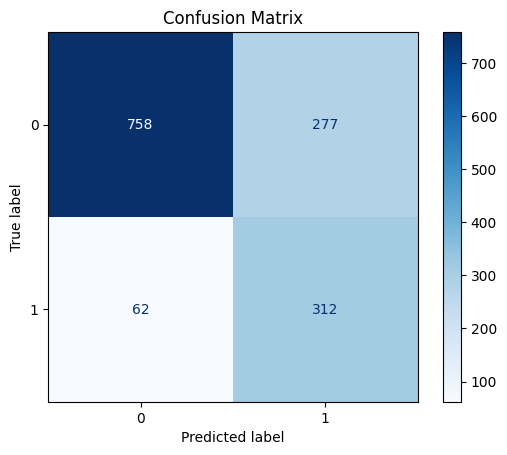

In [20]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state= 7)
X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train)
logistic_rus = LogisticRegression(max_iter=1000, random_state=7)
logistic_rus.fit(X_rus, y_rus)
y_pred = logistic_rus.predict(X_test_scaled)
metrics(y_test, y_pred)
mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=logistic.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [21]:
print(f"Before undersampling: {y_train.value_counts()} \nAfter undersampling: {y_rus.value_counts()}")

Before undersampling: Churn
0    4139
1    1495
Name: count, dtype: int64 
After undersampling: Churn
0    1495
1    1495
Name: count, dtype: int64


# SMOTE technique

Before oversampling: Churn
0    4139
1    1495
Name: count, dtype: int64 
After oversampling: Churn
1    4139
0    4139
Name: count, dtype: int64
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.76      0.83      1035
           1       0.54      0.80      0.65       374

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409

Confusion Matrix:
 [[782 253]
 [ 74 300]]
Accuracy Score: 0.7679205110007097
ROC AUC Score: 0.7788472964943554


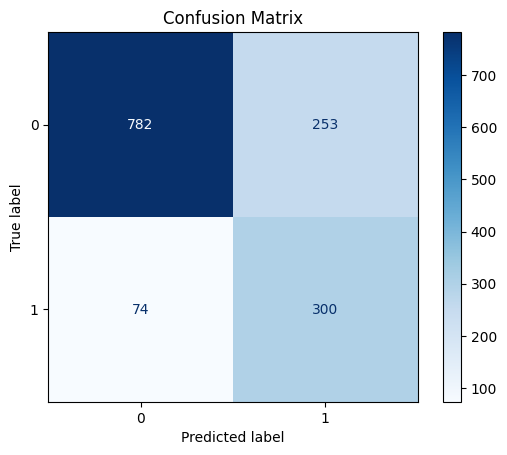

In [22]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=7)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Before oversampling: {y_train.value_counts()} \nAfter oversampling: {y_smote.value_counts()}")
logistic_smote = LogisticRegression(max_iter=1000, random_state=7)
logistic_smote.fit(X_smote, y_smote)
y_pred = logistic_smote.predict(X_test_scaled)
metrics(y_test, y_pred)
mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=logistic.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# SMOTE - sampling strategy

Before oversampling: Churn
0    4139
1    1495
Name: count, dtype: int64 
After oversampling: Churn
0    4139
1    2152
Name: count, dtype: int64
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86      1035
           1       0.61      0.67      0.64       374

    accuracy                           0.80      1409
   macro avg       0.75      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409

Confusion Matrix:
 [[878 157]
 [124 250]]
Accuracy Score: 0.8005677785663591
ROC AUC Score: 0.7583791883024621


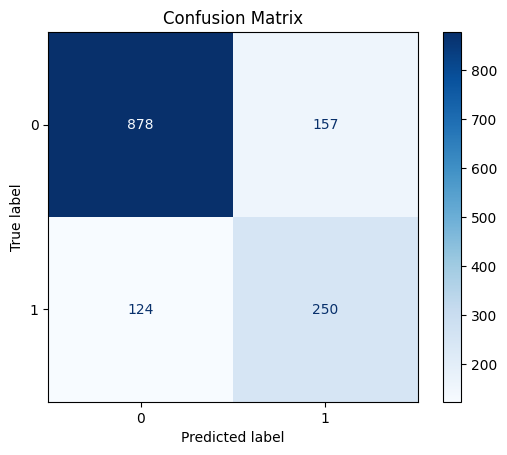

In [23]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy= 0.52,random_state=7)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Before oversampling: {y_train.value_counts()} \nAfter oversampling: {y_smote.value_counts()}")
logistic_smote = LogisticRegression(max_iter=1000, random_state=7)
logistic_smote.fit(X_smote, y_smote)
y_pred = logistic_smote.predict(X_test_scaled)
metrics(y_test, y_pred)
mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=logistic.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# SMOTE TYPES - ADASYN

Before oversampling: Churn
0    4139
1    1495
Name: count, dtype: int64 
After oversampling: Churn
1    4170
0    4139
Name: count, dtype: int64
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.70      0.80      1035
           1       0.50      0.84      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.81      0.74      0.75      1409

Confusion Matrix:
 [[722 313]
 [ 58 316]]
Accuracy Score: 0.7366926898509581
ROC AUC Score: 0.7712521635795293


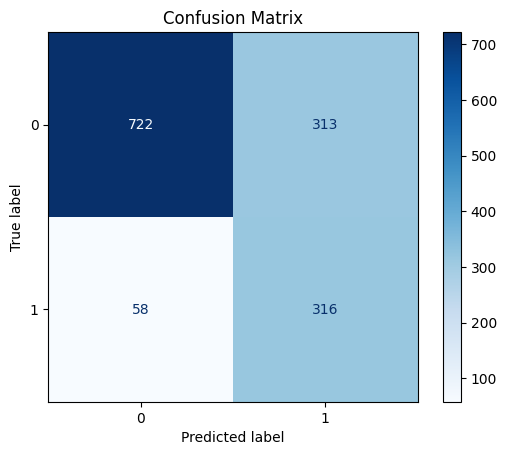

In [24]:
from imblearn.over_sampling import ADASYN
adasyn = ADASYN( random_state=7)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(f"Before oversampling: {y_train.value_counts()} \nAfter oversampling: {y_adasyn.value_counts()}")
logistic_adasyn = LogisticRegression(max_iter=1000, random_state=7)
logistic_adasyn.fit(X_adasyn, y_adasyn)
y_pred = logistic_adasyn.predict(X_test_scaled)
metrics(y_test, y_pred)
mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=logistic_adasyn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Before oversampling: Churn
0    4139
1    1495
Name: count, dtype: int64 
After oversampling: Churn
0    4139
1    2732
Name: count, dtype: int64
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.80      0.85      1035
           1       0.58      0.75      0.65       374

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.81      0.79      0.80      1409

Confusion Matrix:
 [[831 204]
 [ 94 280]]
Accuracy Score: 0.7885024840312278
ROC AUC Score: 0.7757808261644579


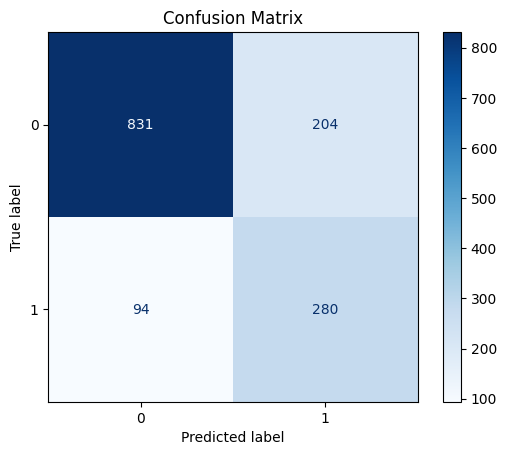

In [25]:
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(sampling_strategy=0.7, random_state=7)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(f"Before oversampling: {y_train.value_counts()} \nAfter oversampling: {y_adasyn.value_counts()}")
logistic_adasyn = LogisticRegression(max_iter=1000, random_state=7)
logistic_adasyn.fit(X_adasyn, y_adasyn)
y_pred = logistic_adasyn.predict(X_test_scaled)
metrics(y_test, y_pred)
mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=logistic_adasyn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# BorderlineSMOTE

Before oversampling: Churn
0    4139
1    1495
Name: count, dtype: int64 
After oversampling: Churn
1    4139
0    4139
Name: count, dtype: int64
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.70      0.80      1035
           1       0.51      0.85      0.64       374

    accuracy                           0.74      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.74      0.76      1409

Confusion Matrix:
 [[726 309]
 [ 56 318]]
Accuracy Score: 0.7409510290986515
ROC AUC Score: 0.7758583275207316


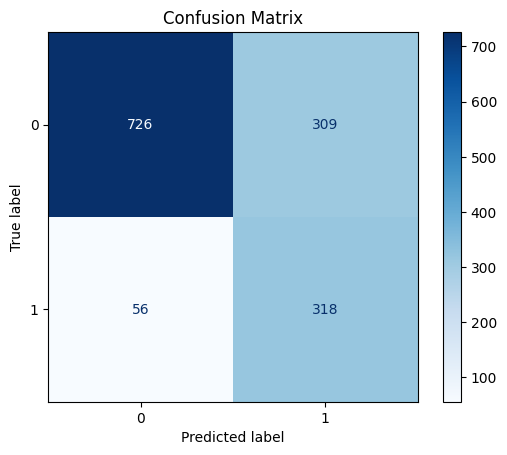

In [26]:
from imblearn.over_sampling import BorderlineSMOTE
adasyn = BorderlineSMOTE(random_state=7)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(f"Before oversampling: {y_train.value_counts()} \nAfter oversampling: {y_adasyn.value_counts()}")
logistic_adasyn = LogisticRegression(max_iter=1000, random_state=7)
logistic_adasyn.fit(X_adasyn, y_adasyn)
y_pred = logistic_adasyn.predict(X_test_scaled)
metrics(y_test, y_pred)
mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=logistic_adasyn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Before oversampling: Churn
0    4139
1    1495
Name: count, dtype: int64 
After oversampling: Churn
0    4139
1    2069
Name: count, dtype: int64
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86      1035
           1       0.62      0.68      0.65       374

    accuracy                           0.80      1409
   macro avg       0.75      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409

Confusion Matrix:
 [[876 159]
 [120 254]]
Accuracy Score: 0.8019872249822569
ROC AUC Score: 0.7627605983104705


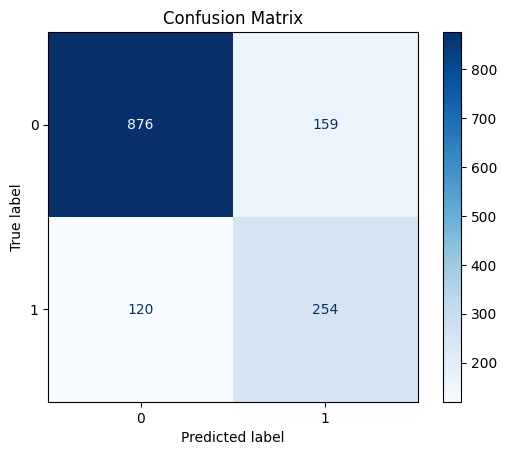

In [27]:
from imblearn.over_sampling import BorderlineSMOTE
adasyn = BorderlineSMOTE(sampling_strategy=0.5,random_state=7)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(f"Before oversampling: {y_train.value_counts()} \nAfter oversampling: {y_adasyn.value_counts()}")
logistic_adasyn = LogisticRegression(max_iter=1000, random_state=7)
logistic_adasyn.fit(X_adasyn, y_adasyn)
y_pred = logistic_adasyn.predict(X_test_scaled)
metrics(y_test, y_pred)
mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=logistic_adasyn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# KMeansSMOTE

Before oversampling: Churn
0    4139
1    1495
Name: count, dtype: int64 
After oversampling: Churn
1    4139
0    4139
Name: count, dtype: int64
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86      1035
           1       0.61      0.68      0.65       374

    accuracy                           0.80      1409
   macro avg       0.75      0.76      0.75      1409
weighted avg       0.81      0.80      0.81      1409

Confusion Matrix:
 [[874 161]
 [118 256]]
Accuracy Score: 0.8019872249822569
ROC AUC Score: 0.7644682115270351


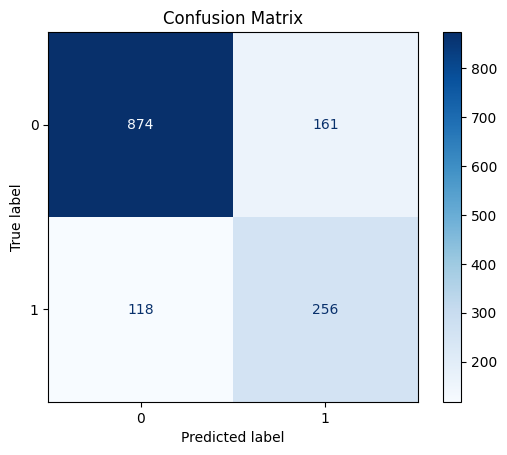

In [28]:
from imblearn.over_sampling import KMeansSMOTE
adasyn = KMeansSMOTE(random_state=7)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(f"Before oversampling: {y_train.value_counts()} \nAfter oversampling: {y_adasyn.value_counts()}")
logistic_adasyn = LogisticRegression(max_iter=1000, random_state=7)
logistic_adasyn.fit(X_adasyn, y_adasyn)
y_pred = logistic_adasyn.predict(X_test_scaled)
metrics(y_test, y_pred)
mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=logistic_adasyn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Before oversampling: Churn
0    4139
1    1495
Name: count, dtype: int64 
After oversampling: Churn
0    4139
1    2897
Name: count, dtype: int64
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.86      0.87      1035
           1       0.62      0.65      0.64       374

    accuracy                           0.80      1409
   macro avg       0.75      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409

Confusion Matrix:
 [[888 147]
 [130 244]]
Accuracy Score: 0.8034066713981547
ROC AUC Score: 0.7551887158025266


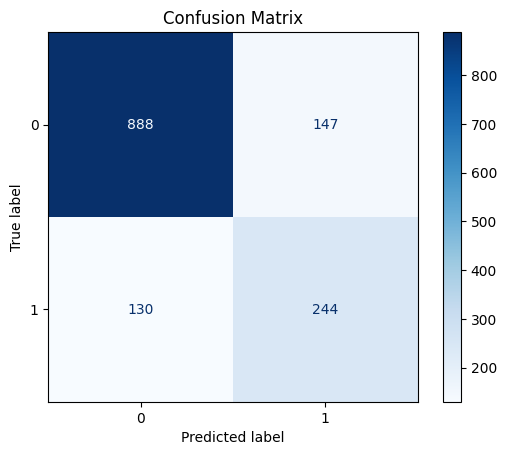

In [29]:
from imblearn.over_sampling import KMeansSMOTE
adasyn = KMeansSMOTE(sampling_strategy=0.7,random_state=7)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(f"Before oversampling: {y_train.value_counts()} \nAfter oversampling: {y_adasyn.value_counts()}")
logistic_adasyn = LogisticRegression(max_iter=1000, random_state=7)
logistic_adasyn.fit(X_adasyn, y_adasyn)
y_pred = logistic_adasyn.predict(X_test_scaled)
metrics(y_test, y_pred)
mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=logistic_adasyn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# SVMSMOTE

Before oversampling: Churn
0    4139
1    1495
Name: count, dtype: int64 
After oversampling: Churn
1    4139
0    4139
Name: count, dtype: int64
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.73      0.82      1035
           1       0.53      0.83      0.65       374

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409

Confusion Matrix:
 [[757 278]
 [ 62 312]]
Accuracy Score: 0.758694109297374
ROC AUC Score: 0.782812782557028


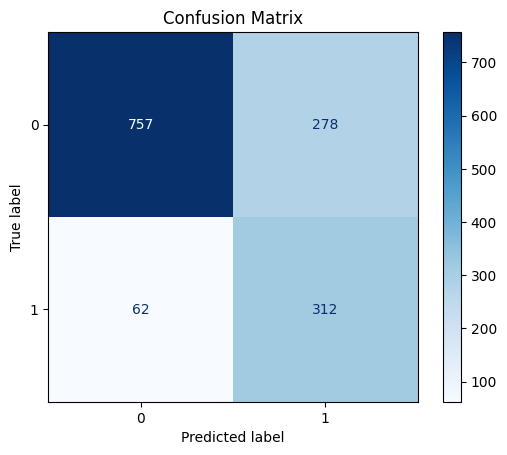

In [30]:
from imblearn.over_sampling import SVMSMOTE
adasyn = SVMSMOTE(random_state=7)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(f"Before oversampling: {y_train.value_counts()} \nAfter oversampling: {y_adasyn.value_counts()}")
logistic_adasyn = LogisticRegression(max_iter=1000, random_state=7)
logistic_adasyn.fit(X_adasyn, y_adasyn)
y_pred = logistic_adasyn.predict(X_test_scaled)
metrics(y_test, y_pred)
mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=logistic_adasyn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Before oversampling: Churn
0    4139
1    1495
Name: count, dtype: int64 
After oversampling: Churn
0    4139
1    2897
Name: count, dtype: int64
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.80      0.85      1035
           1       0.58      0.75      0.65       374

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.79      1409

Confusion Matrix:
 [[830 205]
 [ 95 279]]
Accuracy Score: 0.78708303761533
ROC AUC Score: 0.7739608359812964


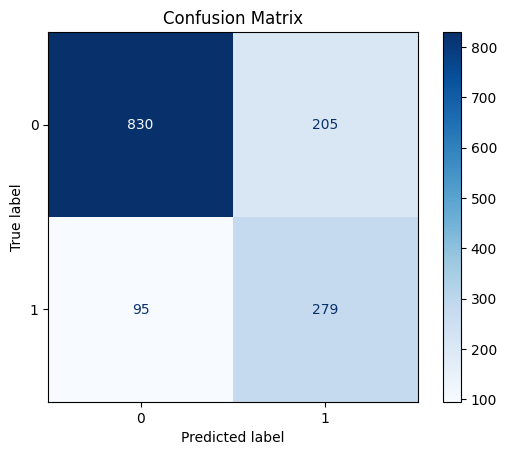

In [31]:
from imblearn.over_sampling import SVMSMOTE
adasyn = SVMSMOTE(sampling_strategy=0.7,random_state=7)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(f"Before oversampling: {y_train.value_counts()} \nAfter oversampling: {y_adasyn.value_counts()}")
logistic_adasyn = LogisticRegression(max_iter=1000, random_state=7)
logistic_adasyn.fit(X_adasyn, y_adasyn)
y_pred = logistic_adasyn.predict(X_test_scaled)
metrics(y_test, y_pred)
mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=logistic_adasyn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [33]:
# model 1 
lr_naive = LogisticRegression(max_iter=1000, random_state=7)
lr_naive.fit(X_train_scaled, y_train)
y_prob_naive = lr_naive.predict_proba(X_test_scaled)[:,1]

# model 2
lr_smote = LogisticRegression(max_iter=1000, random_state=7)
lr_smote.fit(X_smote, y_smote)
y_prob_smote = lr_smote.predict_proba(X_test_scaled)[:,1]

# model 3
dt_smote = DecisionTreeClassifier(max_depth=10, random_state=7)
dt_smote.fit(X_smote, y_smote)
y_prob_dt = dt_smote.predict_proba(X_test_scaled)[:,1]

In [34]:
rf_smote = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=7)
rf_smote.fit(X_smote, y_smote)
y_prob_rf = rf_smote.predict_proba(X_test_scaled)[:,1]

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
def metrics(ytest, ypred, model):
    print("Accuracy: ", accuracy_score(ytest, ypred))
    print("Precision: ", precision_score(ytest, ypred))
    print("Recall: ", recall_score(ytest, ypred))
    mat = confusion_matrix(ytest, ypred)
    disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()
    print("ROC AUC Score:", roc_auc_score(ytest, ypred))
    print("Classification Report:\n", classification_report(ytest, ypred))

Accuracy:  0.8112136266855926
Precision:  0.6741935483870968
Recall:  0.5588235294117647


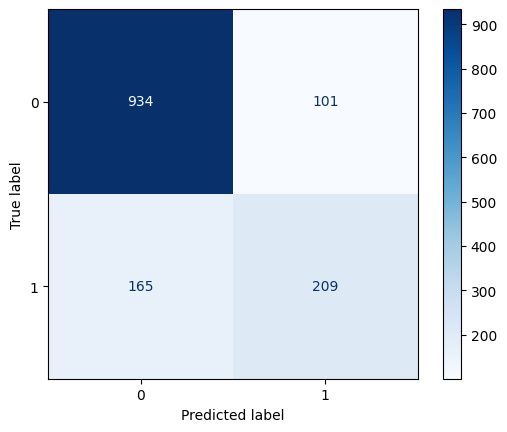

ROC AUC Score: 0.7306194941744815
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.88      1035
           1       0.67      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



In [36]:
# model 1
y_pred_naive = lr_naive.predict(X_test_scaled)
metrics(y_test, y_pred_naive, lr_naive)

Accuracy:  0.8005677785663591
Precision:  0.6142506142506142
Recall:  0.6684491978609626


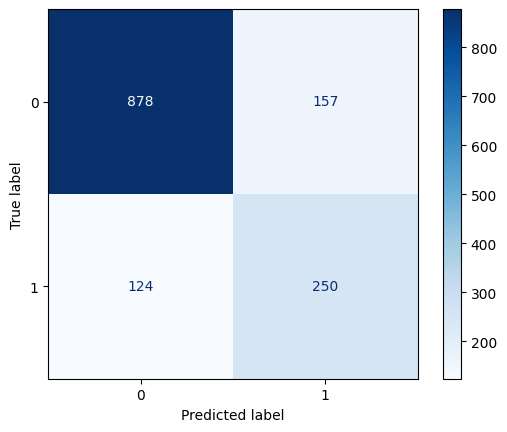

ROC AUC Score: 0.7583791883024621
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86      1035
           1       0.61      0.67      0.64       374

    accuracy                           0.80      1409
   macro avg       0.75      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409



In [37]:
# model 2
y_pred_smote = lr_smote.predict(X_test_scaled)
metrics(y_test, y_pred_smote, lr_smote)

Accuracy:  0.7693399574166075
Precision:  0.5610972568578554
Recall:  0.6016042780748663


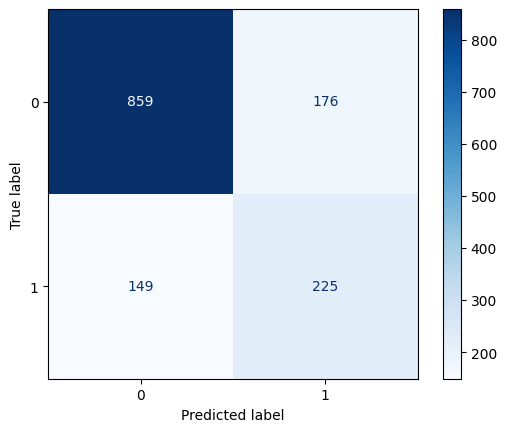

ROC AUC Score: 0.7157779844480612
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.56      0.60      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.77      0.77      0.77      1409



In [38]:
# model 3
y_pred_dt = dt_smote.predict(X_test_scaled)
metrics(y_test, y_pred_dt, dt_smote)

Accuracy:  0.8176011355571328
Precision:  0.6638655462184874
Recall:  0.6336898395721925


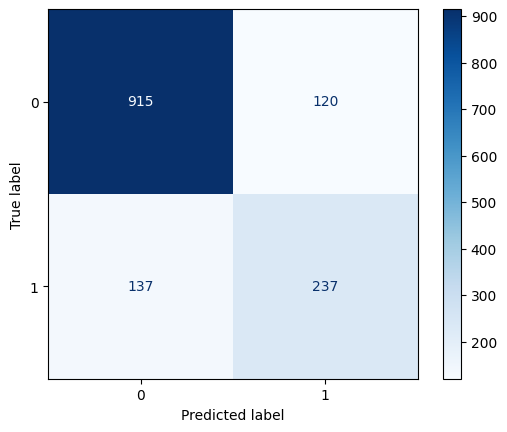

ROC AUC Score: 0.7588739052933428
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.88      0.88      1035
           1       0.66      0.63      0.65       374

    accuracy                           0.82      1409
   macro avg       0.77      0.76      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [39]:
# model 4
y_pred_rf = rf_smote.predict(X_test_scaled)
metrics(y_test, y_pred_rf, rf_smote)

In [50]:
thresholds = np.arange(0.01, 0.99, 0.05)
best_f = 0
best_threshold = 0
print(f"{'Threshold':<10} {'Precision':<10} {'Recall':<10} {'Recall2':<10} {'F1 Score':<10} {'Accuracy':<10} {'TPR':<10} {'FPR':<10}")
for t in thresholds:
    y_pred = (y_prob_rf >= t).astype(int)
    tp, fp, fn, tn = confusion_matrix(y_test, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall1 = tp / (tp + fn) if (tp + fn) > 0 else 0
    recall2 = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall1) / (precision + recall1) if (precision + recall1) > 0 else 0
    acc = (tp + tn) / (tp + fp + fn + tn)
    tpr = recall1
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    if f1 > best_f:
        best_f = f1
        best_threshold = t
    print(f"{t:<10.2f} {precision:<10.4f} {recall1:<10.4f} {recall2:<10.4f} {f1:<10.4f} {acc:<10.4f} {tpr:<10.4f} {fpr:<10.4f}")
print(f"Best Threshold: {best_threshold:.2f}, Best F1 Score: {best_f:.4f}")
print("Classification Report at Optimal Threshold:\n", classification_report(y_test, (y_prob_rf >= best_threshold).astype(int)))

Threshold  Precision  Recall     Recall2    F1 Score   Accuracy   TPR        FPR       
0.01       0.1179     0.9760     0.2889     0.2103     0.3499     0.9760     0.7111    
0.06       0.3053     0.9783     0.3379     0.4654     0.4847     0.9783     0.6621    
0.11       0.4126     0.9749     0.3738     0.5798     0.5607     0.9749     0.6262    
0.16       0.5275     0.9647     0.4199     0.6821     0.6388     0.9647     0.5801    
0.21       0.6193     0.9413     0.4588     0.7471     0.6920     0.9413     0.5412    
0.26       0.6831     0.9278     0.4930     0.7869     0.7282     0.9278     0.5070    
0.31       0.7440     0.9189     0.5359     0.8222     0.7637     0.9189     0.4641    
0.36       0.7942     0.9023     0.5723     0.8448     0.7857     0.9023     0.4277    
0.41       0.8280     0.8899     0.6009     0.8579     0.7984     0.8899     0.3991    
0.46       0.8667     0.8829     0.6489     0.8747     0.8176     0.8829     0.3511    
0.51       0.8908     0.8674    

In [54]:
thresholds = np.arange(0.05, 0.96, 0.05)

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'FP':>8} {'FN':>8}")
print("-" * 60)

best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    y_pred_t = (y_prob_rf >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    if f > best_f1:
        best_f1 = f
        best_thresh = t

    print(f"{t:>10.2f} {p:>10.4f} {r:>10.4f} {f:>10.4f} {fp:>8,} {fn:>8}")

print(f"\nBest F1 threshold: {best_thresh:.2f} (F1 = {best_f1:.4f})")


 Threshold  Precision     Recall         F1       FP       FN
------------------------------------------------------------
      0.05     0.3286     0.9840     0.4926      752        6
      0.10     0.3651     0.9733     0.5310      633       10
      0.15     0.4080     0.9492     0.5707      515       19
      0.20     0.4501     0.9037     0.6009      413       36
      0.25     0.4954     0.8636     0.6296      329       51
      0.30     0.5221     0.8209     0.6383      281       67
      0.35     0.5667     0.7727     0.6538      221       85
      0.40     0.5982     0.7246     0.6554      182      103
      0.45     0.6425     0.6872     0.6641      143      117
      0.50     0.6639     0.6337     0.6484      120      137
      0.55     0.6865     0.5561     0.6145       95      166
      0.60     0.7390     0.4920     0.5907       65      190
      0.65     0.7766     0.4091     0.5359       44      221
      0.70     0.7919     0.3155     0.4512       31      256
      0.7

F1 score:  0.6640826873385013
Accuracy:  0.815471965933286
Precision:  0.6425
Recall:  0.6871657754010695


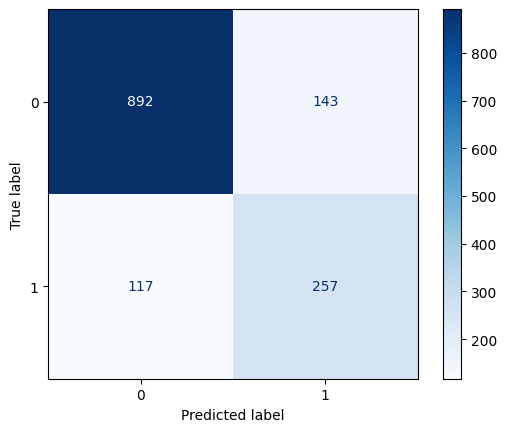

ROC AUC Score: 0.77450076209667
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      1035
           1       0.64      0.69      0.66       374

    accuracy                           0.82      1409
   macro avg       0.76      0.77      0.77      1409
weighted avg       0.82      0.82      0.82      1409



In [55]:
from sklearn.metrics import f1_score
y_pred_optimal = (y_prob_rf >= best_thresh).astype(int)
print("F1 score: ", f1_score(y_test, y_pred_optimal))
metrics(y_test, y_pred_optimal, rf_smote)

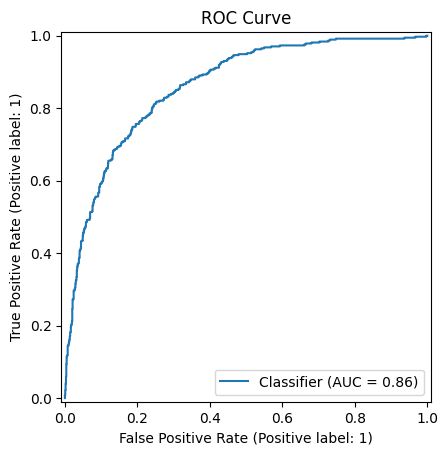

In [56]:
from sklearn.metrics import RocCurveDisplay,roc_curve
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("ROC Curve")
plt.show()

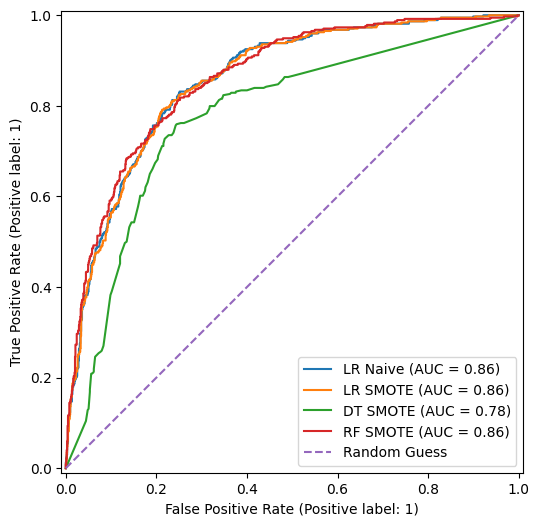

In [57]:
models = {
    'LR Naive': y_prob_naive,
    'LR SMOTE': y_prob_smote,
    'DT SMOTE': y_prob_dt,
    'RF SMOTE': y_prob_rf
}
fig, ax = plt.subplots(figsize=(8,6))
for name, probs in models.items():
    RocCurveDisplay.from_predictions(y_test, probs, name=name,ax=ax)
ax.plot([0,1], [0,1], '--', label='Random Guess')
ax.legend(loc='lower right')
plt.show()

Threshold: 0.1, TPR: 1.0000, FPR: 1.0000
Threshold: 0.2, TPR: 1.0000, FPR: 0.8000
Threshold: 0.3, TPR: 1.0000, FPR: 0.6000
Threshold: 0.4, TPR: 1.0000, FPR: 0.4000
Threshold: 0.5, TPR: 1.0000, FPR: 0.2000
Threshold: 0.6, TPR: 1.0000, FPR: 0.0000
Threshold: 0.7, TPR: 0.8000, FPR: 0.0000
Threshold: 0.8, TPR: 0.6000, FPR: 0.0000
Threshold: 0.9, TPR: 0.2000, FPR: 0.0000
AUC: 0.9200


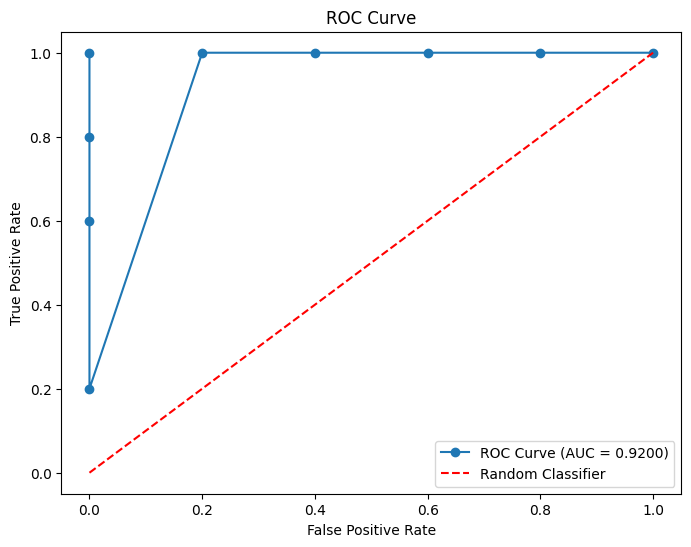

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def compute_and_plot_roc(y_true, y_prob):
    # TODO: define threshold list
    thresholds = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
    # TODO: for each threshold compute TP, FP, FN, TN
    tup = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        tn = np.sum((y_true == 0) & (y_pred == 0))
    # TODO: compute TPR and FPR, handle zero denominators
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    # TODO: collect (fpr, tpr) pairs
        tup.append((fpr, tpr))
        print(f"Threshold: {t:.1f}, TPR: {tpr:.4f}, FPR: {fpr:.4f}")
    # TODO: sort by FPR
    tup.sort(key = lambda x: x[0])
    # TODO: compute AUC with numpy.trapezoid
    fprs, tprs = zip(*tup)
    auc = np.trapz(tprs, fprs)
    print(f"AUC: {auc:.4f}")
    # TODO: plot curve and diagonal reference line
    plt.figure(figsize=(8,6))
    plt.plot(fprs, tprs, marker = 'o', label=f'ROC Curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    y_true = np.array([1, 0, 1, 0, 1, 0, 0, 1, 0, 1])
    y_prob = np.array([0.85, 0.20, 0.75, 0.35, 0.90, 0.45, 0.10, 0.65, 0.55, 0.80])
    compute_and_plot_roc(y_true, y_prob)

Threshold: 0.1, TPR: 1.0000, FPR: 1.0000
Threshold: 0.2, TPR: 1.0000, FPR: 0.8000
Threshold: 0.3, TPR: 1.0000, FPR: 0.6000
Threshold: 0.4, TPR: 1.0000, FPR: 0.4000
Threshold: 0.5, TPR: 1.0000, FPR: 0.2000
Threshold: 0.6, TPR: 1.0000, FPR: 0.0000
Threshold: 0.7, TPR: 0.8000, FPR: 0.0000
Threshold: 0.8, TPR: 0.6000, FPR: 0.0000
Threshold: 0.9, TPR: 0.2000, FPR: 0.0000
AUC: 0.9200


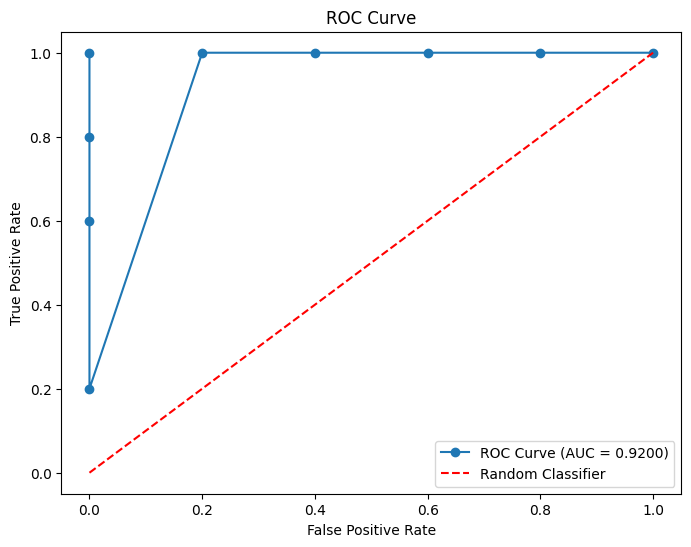

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def compute_and_plot_roc(y_true, y_prob):
    # Ensure inputs are numpy arrays
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    # Define threshold list
    thresholds = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
    points = []

    for t in thresholds:
        # Classify based on threshold
        y_pred = (y_prob >= t).astype(int)

        # Compute confusion matrix components
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        tn = np.sum((y_true == 0) & (y_pred == 0))

        # Compute TPR and FPR with safe division
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        points.append((fpr, tpr))
        print(f"Threshold: {t:.1f}, TPR: {tpr:.4f}, FPR: {fpr:.4f}")

    # Sort points by FPR
    points.sort(key=lambda x: x[0])
    fprs, tprs = zip(*points)

    # Compute AUC using trapezoidal rule
    auc = np.trapz(tprs, fprs)
    print(f"AUC: {auc:.4f}")

    # Plot ROC curve
    plt.figure(figsize=(8,6))
    plt.plot(fprs, tprs, marker='o', label=f'ROC Curve (AUC = {auc:.4f})')
    plt.plot([0,1],[0,1], color='red', linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    y_true = [1, 0, 1, 0, 1, 0, 0, 1, 0, 1]
    y_prob = [0.85, 0.20, 0.75, 0.35, 0.90, 0.45, 0.10, 0.65, 0.55, 0.80]
    compute_and_plot_roc(y_true, y_prob)
